In [1]:
import os
from pathlib import Path

import bento as bt
import matplotlib.pyplot as plt
import seaborn as sns

data_folder_path = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

/dh-projects/ag-ishaque/analysis/muellni/envs/bento/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
analysis_path = Path(".")
script_file = Path("run_bento.py")

memory = 256  # in GB
time = 24  # in h
n_threads = 16

# command for activating conda environment
conda_env = "bento"
conda_path = "~/miniconda3/bin/activate"

conda_cmd = f"source {conda_path} {conda_env}"

log = analysis_path / "bento_log.txt"
out = analysis_path / "bento.pickle"
cmd = (
    f"{script_file.resolve()} {data_folder_path} {out.resolve()} "
    f"--n_threads {n_threads} "
)

In [6]:
id_string = os.popen(
    f"sbatch -J bento --mem={memory}G -c {n_threads} -n 1 "
    f"-o {log} "
    f"--time={time}:00:00 "
    f'--wrap="{conda_cmd} && {cmd}" '
).read()
id_string = id_string.strip()

print(id_string)

Submitted batch job 4313078


In [3]:
import pickle

with open(out, "rb") as file:
    sdata = pickle.load(file)

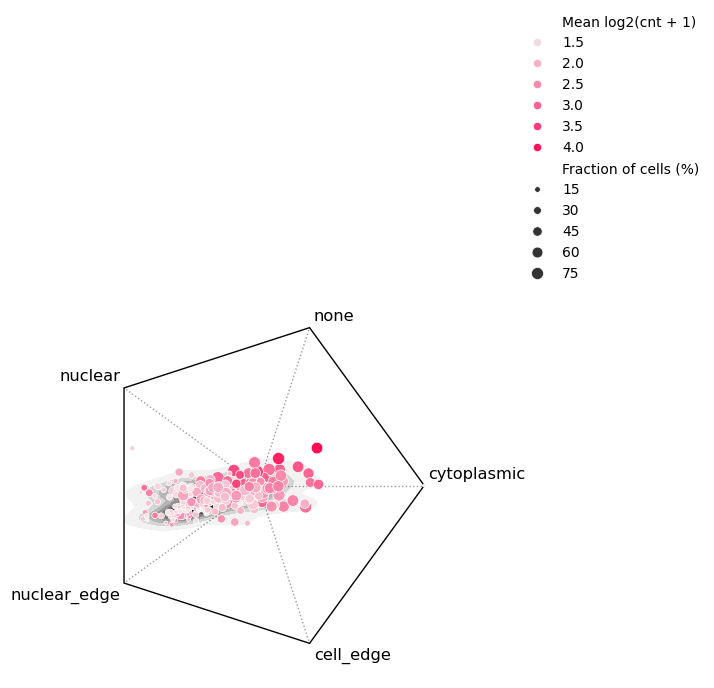

In [4]:
bt.pl.lp_genes(sdata)

In [5]:
lp_stats = sdata.tables["table"].uns["lp_stats"]

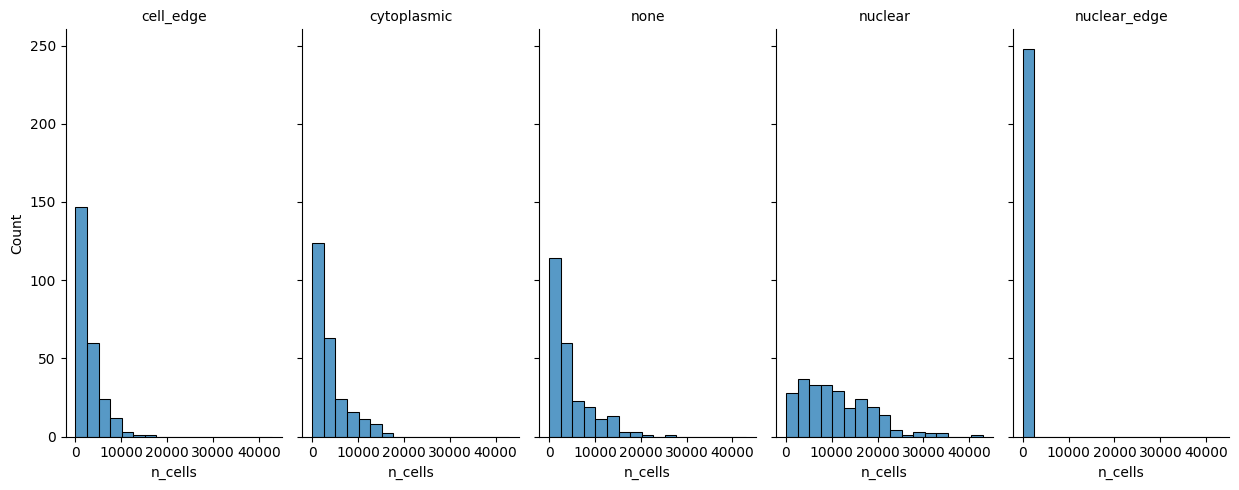

In [6]:
fg = sns.displot(
    data=lp_stats.melt(var_name="localization", value_name="n_cells"),
    col="localization",
    kind="hist",
    x="n_cells",
    binwidth=2_500,
    aspect=0.5,
)
fg.set_titles(col_template="{col_name}")

fg.fig

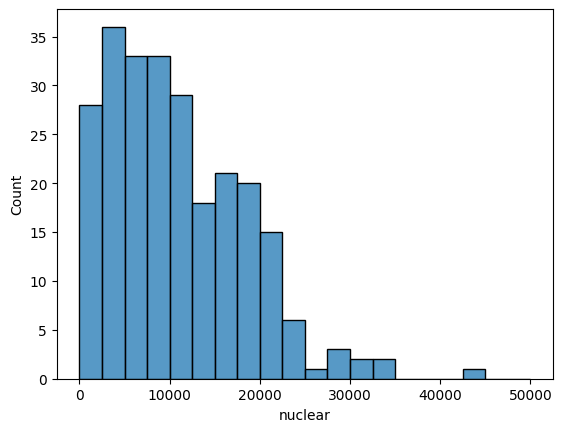

In [7]:
fig, ax = plt.subplots()
sns.histplot(data=lp_stats, x="nuclear", ax=ax, binwidth=2_500, binrange=(0, 50_000))

fig

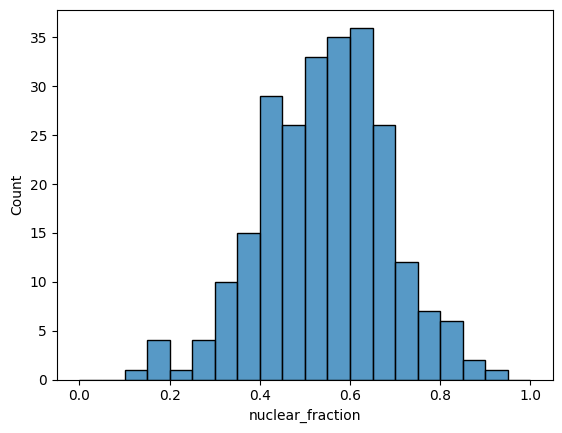

In [8]:
# nuclear fraction here means fraction of cells where the gene is assigned as nuclear
lp_stats = lp_stats.assign(
    n=lambda df: df.sum(axis=1),
    nuclear_fraction=lambda df: df["nuclear"] / df["n"],
)

fig, ax = plt.subplots()
sns.histplot(data=lp_stats, x="nuclear_fraction", ax=ax, binrange=(0, 1), binwidth=0.05)

fig

In [9]:
nuclear_genes = lp_stats.loc[
    lambda df: (df["nuclear_fraction"] >= 0.5) & (df["nuclear"] >= 15_000)
]

nuclear_genes = nuclear_genes.index.tolist()

In [10]:
with open("nuclear_genes.txt", "w") as fp:
    fp.write("\n".join(nuclear_genes))